# **1. Project Overview**

## 1.1 Business Objective

The objective of this project is building machine learning models that can accurately predict housing prices based on property characteristics.
Accurate housing price predictions can support real estate agencies, buyers, sellers, and property investors in making informed decisions.
The model help find key factors influencing house prices and improve pricing consistency in the housing market.

## 1.2 Hypothesis

It is hypothesised that housing prices are influenced by factors related to property quality, size, age, and functionality.
Features such as `Overall Qual`, `Gr Liv Area`, `Year Built`, `Exter Qual`, and `TotRms AbvGrd` are expected to positively influence `SalePrice`, as larger and higher quality properties are generally associated with higher market value. Additionally, the combined effect of overall quality and overall condition may provide stronger predictive power since both construction quality and maintenance status can influence buyer perception.
Particularly in the context of American suburban housing where storage and parking space are considered valuable, features such as `Garage Area` and `Total Bsmt SF` are also expected to contribute to housing prices.

## 1.3 Experiment Objective

The objective of this experiment is to perform exploratory data analysis (EDA) on the Ames Housing dataset to better understand the dataset structure, identify important variables related to housing prices, detect potential data quality issues, and generate insights that may support future predictive modeling experiments.

# **2. Data Understanding**

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

## 2.1 Load Dataset

In [2]:
# Load Dataset
df = pd.read_csv("../data/raw/AmesHousing.csv")

## 2.2 Dataset Overview

In [3]:
# Summary of Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [4]:
# Dimension of Dataset
df.shape

(2930, 82)

In [5]:
# First 5 rows
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [6]:
# The descriptive statistics of df
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [7]:
df.describe(include = 'object')

/var/folders/_t/rkgjf8416szg87k124454j1m0000gn/T/ipykernel_9823/1466716981.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = 'object')


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


In [8]:
# Check Missing Values
df.isnull().sum().sort_values(ascending=False)

Pool QC         2917
Misc Feature    2824
Alley           2732
Fence           2358
Mas Vnr Type    1775
                ... 
PID                0
Central Air        0
1st Flr SF         0
2nd Flr SF         0
SalePrice          0
Length: 82, dtype: int64

In [9]:
# Check duplicated valuex
df.duplicated().sum()

np.int64(0)

## 2.3 Explore Target Variable

In [10]:
# Statistics of Target Feature
df['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Count'>

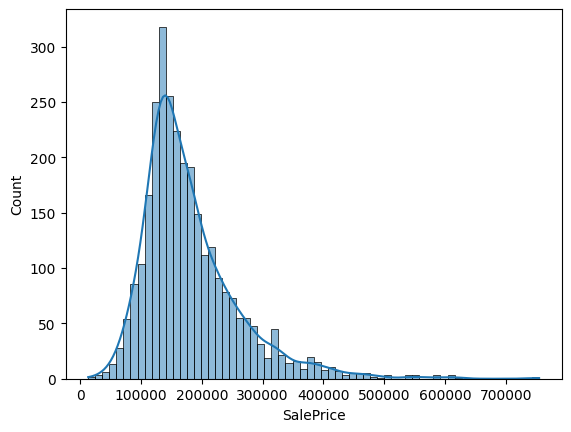

In [11]:
# Histogram of Target
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['SalePrice'], kde = True)

In [12]:
# Skewness of Target
df['SalePrice'].skew()

np.float64(1.7435000757376466)

<Axes: xlabel='SalePrice'>

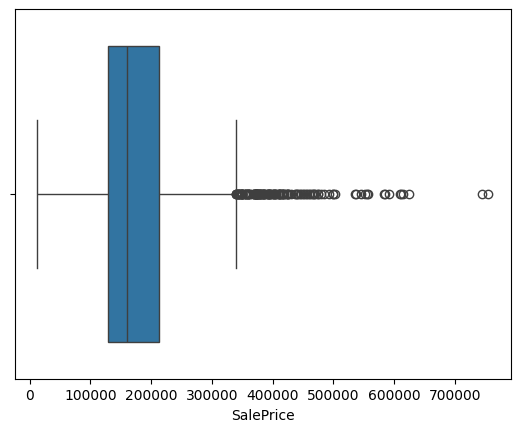

In [13]:
# Boxplot of Target
sns.boxplot(x=df["SalePrice"])

### **Insights**
**The target variable `SalePrice` shows a positively skewed distribution with a long right tail. This indicates that a small number of houses have substantially higher prices compared to the majority of properties. The skewness value suggests that log transformation may be considered in future modeling experiments to improve distribution symmetry and model stability. And the target variable contains several high-value properties that may represent potential outliers. These observations may require further investigation during the modelling stage.**

## 2.4 Explore Numerical Features

In [14]:
# Select Numerical Features
numerical_features = df.select_dtypes(include = ['int64', 'float']).columns
numerical_features

Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='str')

In [15]:
# Correlation with Target
correlation = df[numerical_features].corr()['SalePrice'].sort_values(ascending = False)
correlation

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

In [16]:
# Top Correlation Features
top_corr = correlation[1:10]
top_corr

Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64

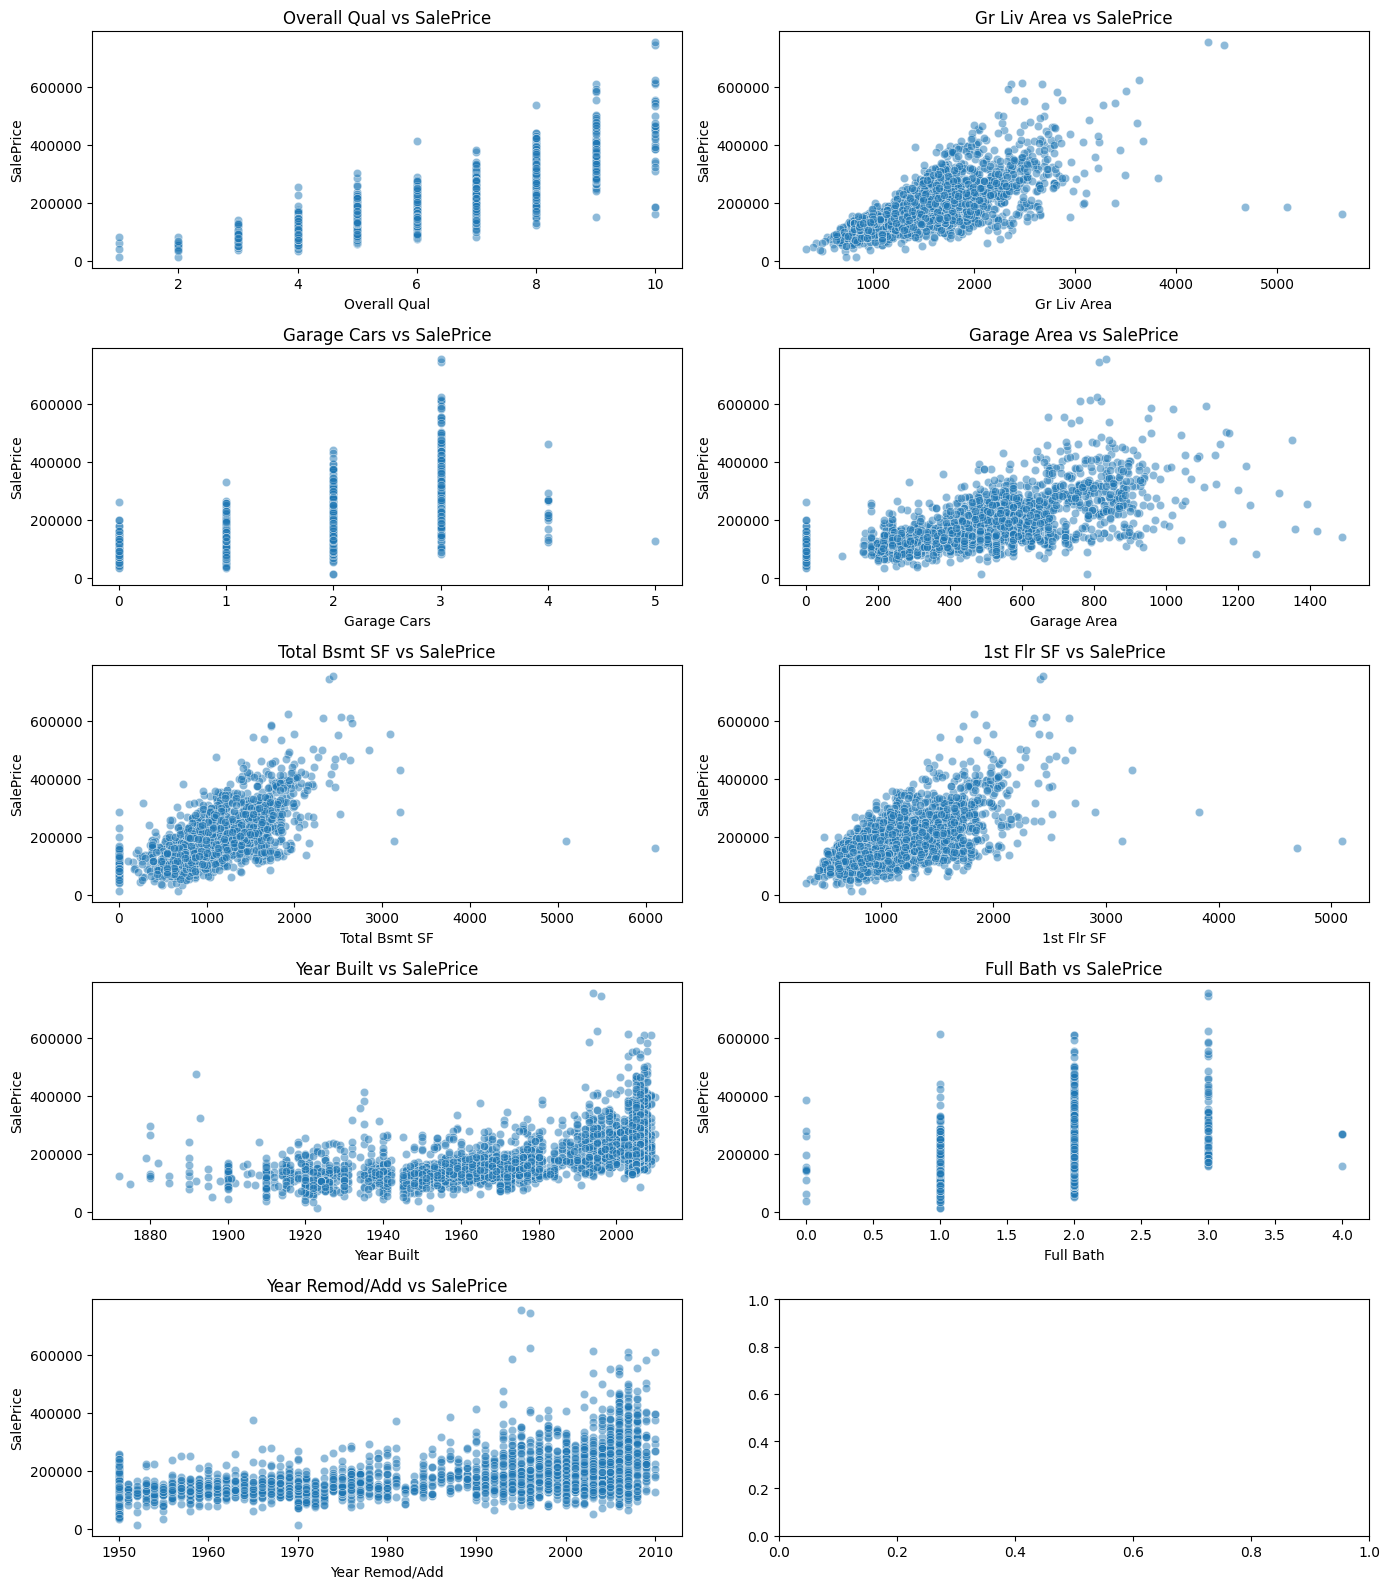

In [17]:
# Scatterplot of Top correlated features vs Target
fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize = (14,16))
axes = axes.flatten()

for i, feature in enumerate (top_corr.index):
    sns.scatterplot(
        x = df[feature],
        y = df['SalePrice'],
        ax = axes[i],
        alpha = 0.5
    )
    axes[i].set_title(f"{feature} vs SalePrice")

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

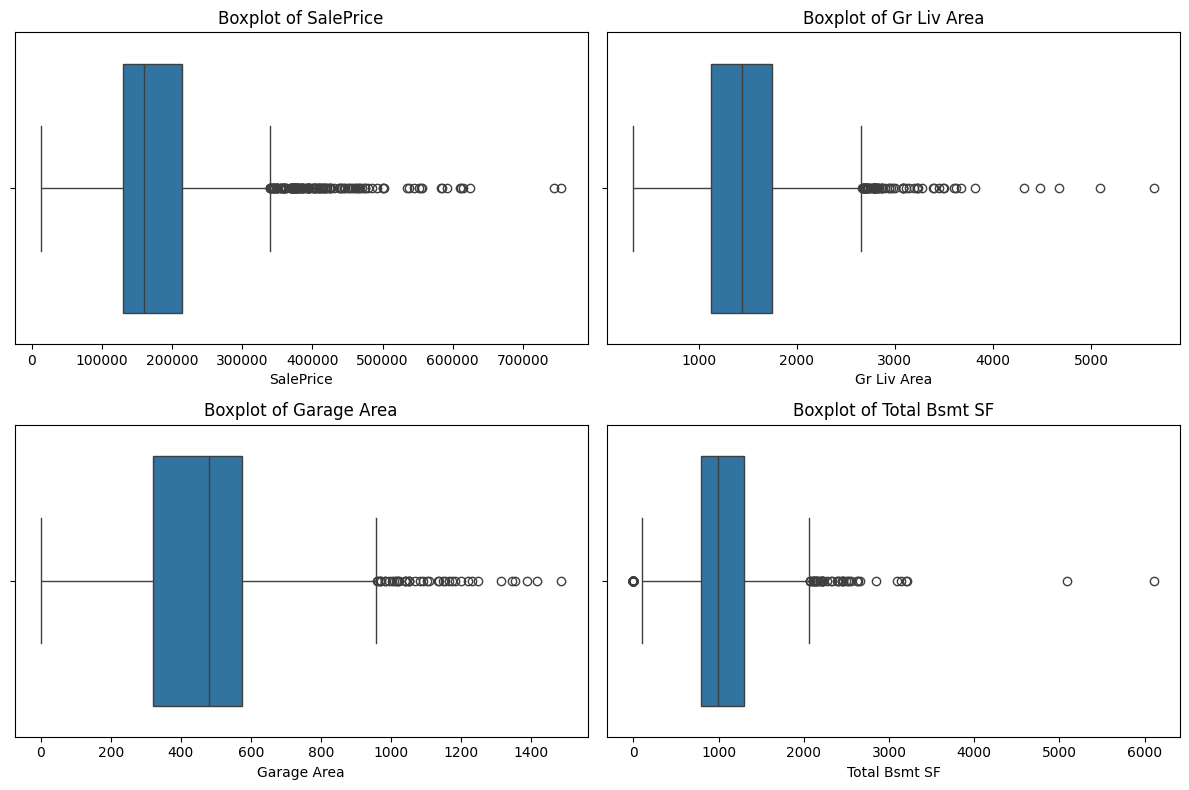

In [18]:
# Check Outliers
# Boxplots of Important Numerical Features
important_features = ['SalePrice', 'Gr Liv Area', 'Garage Area', 'Total Bsmt SF']

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12,8))
axes = axes.flatten()

for i, feature in enumerate(important_features):
    sns.boxplot(
        x = df[feature],
        ax = axes[i]
    )
    axes[i].set_title(f"Boxplot of {feature}")
    
plt.tight_layout()
plt.show    

<function matplotlib.pyplot.show(close=None, block=None)>

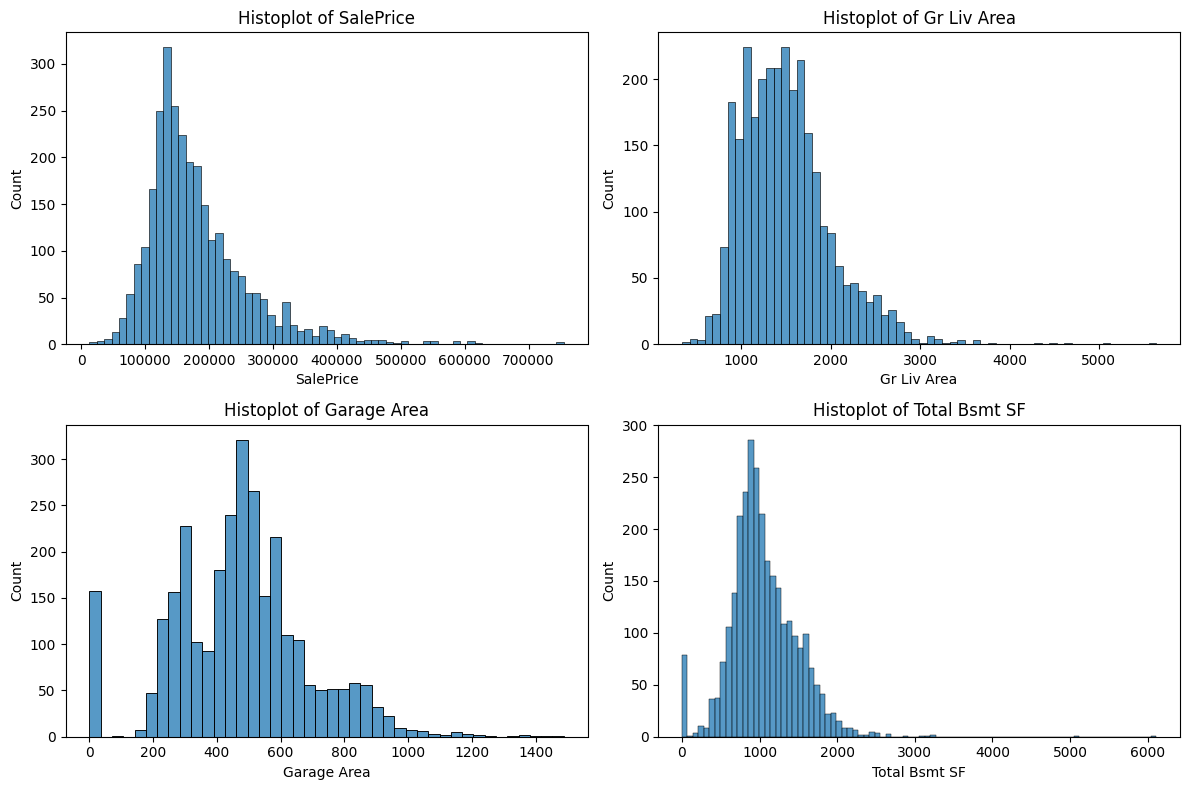

In [19]:
# Distribution of Important Numerical Features
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12,8))
axes = axes.flatten()

for i, feature in enumerate(important_features):
    sns.histplot(
        x = df[feature],
        ax = axes[i]   
    )
    axes[i].set_title(f"Histoplot of {feature}")
    
plt.tight_layout()
plt.show

### **Insights**
- **Correlation analysis showed that several numerical features have strong positive relationships with target variable `SalePrice`. Among them, `Overall Qual` showed the strongest correlation with the target. It indicates that overall housing quality is one of the most important factors influencing housing prices.**
- **Scatter plots confirmed positive relationships between important numerical features. Particularly, houses with higher overall quality, larger living area, bigger garage area and larger basement area tended to have higher sale prices.**
- **Scatter plots also shows that potential outliers, especially for `Gr Liv Area` and `Total Bsmt SF` where a small number of houses had unusually large sizes compared to their sale prices.**
- **Boxplots and Histoplots were performed on `SalePrice`, `Gr Liv Area` and `Total Bsmt SF` to investigate the distribution of important numerical features. The results showed that these variables generally exhibit right-skewed with long right tails.**
- **The presence of skewed distribution and potential outliers suggests that transformation techniques such as log transformation may be considered during the future experiments to improve model stability.**

## 2.5 Explore Categorical Features

In [20]:
# Select Categorical Features
categorical_features = df.select_dtypes(include='object').columns
categorical_features

/var/folders/_t/rkgjf8416szg87k124454j1m0000gn/T/ipykernel_9823/1336767741.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include='object').columns


Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='str')

In [21]:
# Select Important Categorical Features
important_cat = ['MS Zoning', 'Neighborhood', 'House Style', 'Exter Qual', 'Exter Cond','Kitchen Qual']

In [22]:
# Category Frequency of important_cat
for feature in important_cat:
    print(feature) 
    display(
        pd.DataFrame({
            "Count": df[feature].value_counts(),
            "Percentage(%)": round(df[feature].value_counts(normalize = True) * 100, 2)
            })
        )

MS Zoning


,Count,Percentage(%)
MS Zoning,,
RL,2273,77.58
RM,462,15.77
FV,139,4.74
RH,27,0.92
C (all),25,0.85
I (all),2,0.07
A (agr),2,0.07


Neighborhood


,Count,Percentage(%)
Neighborhood,,
NAmes,443,15.12
CollgCr,267,9.11
OldTown,239,8.16
Edwards,194,6.62
Somerst,182,6.21
NridgHt,166,5.67
Gilbert,165,5.63
Sawyer,151,5.15
NWAmes,131,4.47


House Style


...

,Count,Percentage(%)
Exter Qual,,
TA,1799,61.40
Gd,989,33.75
Ex,107,3.65
Fa,35,1.19


Exter Cond


,Count,Percentage(%)
Exter Cond,,
TA,2549,87.00
Gd,299,10.20
Fa,67,2.29
Ex,12,0.41
Po,3,0.10


Kitchen Qual


,Count,Percentage(%)
Kitchen Qual,,
TA,1494,50.99
Gd,1160,39.59
Ex,205,7.00
Fa,70,2.39
Po,1,0.03


In [23]:
# SalePrice Comparison
for feature in important_cat:
    print(feature)
    display(
        df.groupby(feature)['SalePrice']
        .agg(['count', 'mean', 'median'])
            .sort_values('mean', ascending=False)
    )

MS Zoning


,count,mean,median
MS Zoning,,,
FV,139,218986.949640,209000.0
RL,2273,191283.251650,172000.0
RH,27,136419.777778,140000.0
RM,462,126781.393939,120750.0
I (all),2,80312.500000,80312.5
C (all),25,79795.040000,78000.0
A (agr),2,47300.000000,47300.0


Neighborhood


,count,mean,median
Neighborhood,,,
NoRidge,71,330319.126761,302000.0
StoneBr,51,324229.196078,319000.0
NridgHt,166,322018.265060,317750.0
GrnHill,2,280000.000000,280000.0
Veenker,24,248314.583333,250250.0
Timber,72,246599.541667,232106.5
Somerst,182,229707.324176,225500.0
ClearCr,44,208662.090909,197500.0
Crawfor,103,207550.834951,200624.0


House Style


...

,count,mean,median
Exter Qual,,,
Ex,107,377918.616822,370967.0
Gd,989,230756.384226,219500.0
TA,1799,143373.968316,139000.0
Fa,35,89923.742857,85000.0


Exter Cond


,count,mean,median
Exter Cond,,,
Ex,12,217699.750000,167000.0
TA,2549,184421.103570,165000.0
Gd,299,165803.762542,147000.0
Fa,67,107563.298507,104000.0
Po,3,82866.666667,76500.0


Kitchen Qual


,count,mean,median
Kitchen Qual,,,
Ex,205,337339.341463,325624.0
Gd,1160,210835.582759,201000.0
TA,1494,139549.947791,136500.0
Po,1,107500.000000,107500.0
Fa,70,105907.042857,107750.0


<function matplotlib.pyplot.show(close=None, block=None)>

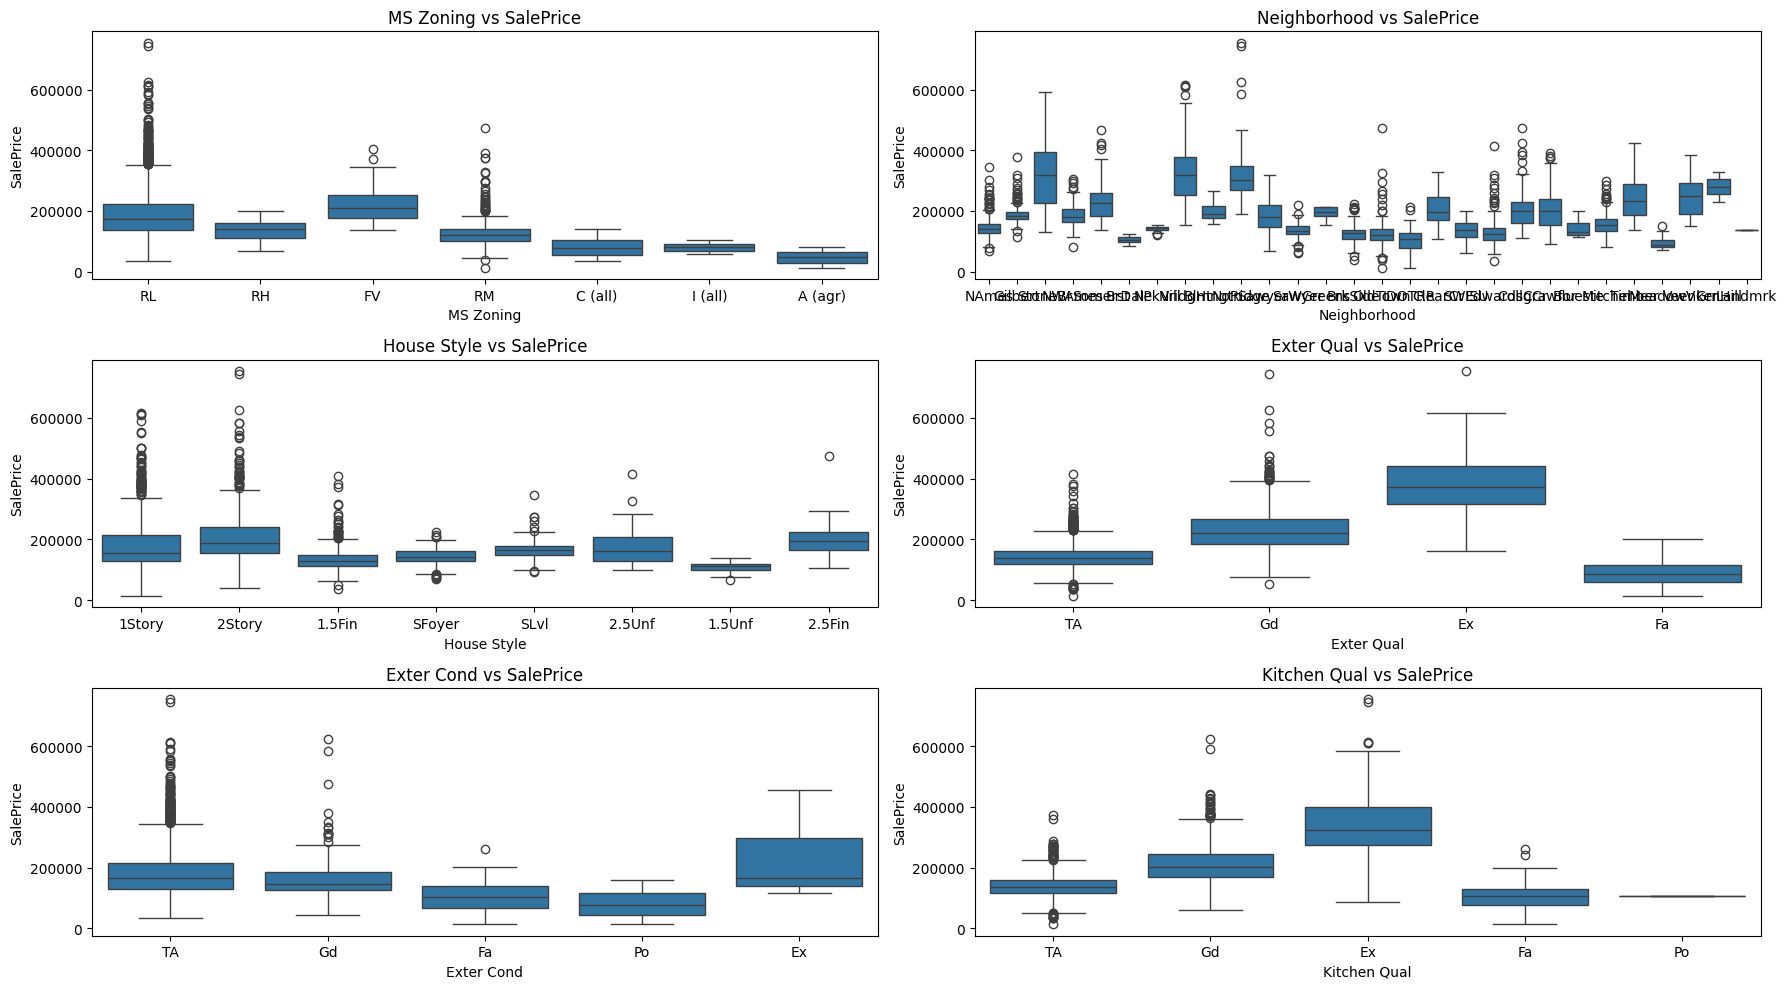

In [24]:
# Boxplots of important_cat
fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (18,10))
axes = axes.flatten()

for i, feature in enumerate(important_cat):
    sns.boxplot(
        x = df[feature],
        y = df['SalePrice'],
        ax = axes[i]
        )
    axes[i].set_title(f"{feature} vs SalePrice")
    
plt.tight_layout()
plt.show

### **Insights**
**Several categorical features appear to have meaningful relationships with `SalePrice`.**
- **`Neighborhood` showed substantial differences in housing prices across location. It indicates that location is a major factor influencing property value. Neighborhood such as NoRidge, StoneBr and NridgHt showed much higher prices(>300k) that other areas.**
- **Property quality-related variables also indicates strong relationships with target. Houses with higher exterior quality(`Exter Qual`) and kitchen quality(`Kitchen Qual`) achieved higher sale prices. It suggests that overall construction quality play an important role in housing valuation.**
- **`MS Zoning` and `House Style` showed moderate differences in sale prices across categories. However, `Exter Cond` showed relatively weaker separation between categories and may have less influence on housing prices compared to quality-related features.**

# **3. Feature Selection**

## 3.1 Correlation with Target

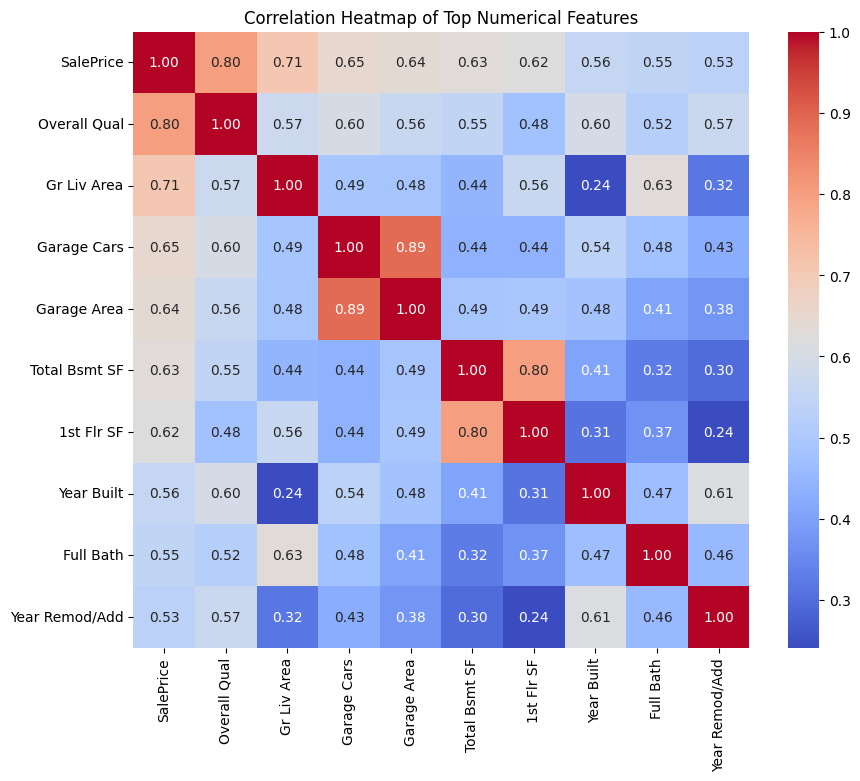

In [25]:
# Correlation Heatmap of Top correlated Features
heatmap_features = ['SalePrice'] + list(top_corr.index)
corr_matrix = df[heatmap_features].corr()

plt.figure(figsize = (10, 8))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f',
    square = True
)

plt.title('Correlation Heatmap of Top Numerical Features')
plt.show()

### **Insights**
- **Correlation Heatmap identified several numerical features that show strong positive relationships with `SalePrice`. `Overall Qual` showed the strongest correlation with the target variable (r = 0.80).**
- **The correlation heatmap also revealed strong relationships among several predictor variables. `Garage Cars` and `Garage Area` showed a very high correlation (r = 0.89). Also, `Total Bsmt SF` and `1st Flr SF` showed a strong correlation (r = 0.80). These findings suggest potential multicollinearity among some numerical features. It may require further consideration during the modeling stage.**


## 3.2 Feature Evaluation

- **Numerical Features:** `Overall Qual` demonstrated the strongest relationship with target, followed by `Gr Liv Area`, `Garage Cars`, and `Total Bsmt SF`. Scatterplots showed clear positive relationships with housing prices, while distribution analysis revealed right-skewed distributions and potential outliers in several variable.
- **Categorical Feature:** `Neighborhood`, `Exter Qual`, and `Kitchen Qual` displayed substantial differences in `SalePrice` across categories. These features showed strong potential predictive value and are likely to contribute meaningfully to housing price prediction.


## 3.3 Candidate Features

In [29]:
Num_candidate_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath']
Cat_candidate_features = ['Neighborhood', 'MS Zoning', 'Exter Qual', 'Kitchen Qual']

candidate_table = pd.DataFrame({
    'Feature': Num_candidate_features + Cat_candidate_features,
    'Type': ['Numerical']*len(Num_candidate_features) +
            ['Categorical']*len(Cat_candidate_features)
})

candidate_table

,Feature,Type
0,Overall Qual,Numerical
1,Gr Liv Area,Numerical
2,Garage Cars,Numerical
3,Garage Area,Numerical
4,Total Bsmt SF,Numerical
5,1st Flr SF,Numerical
6,Year Built,Numerical
7,Full Bath,Numerical
8,Neighborhood,Categorical
9,MS Zoning,Categorical


## 3.4 Features for Further Investigation

`House Style` and `Exter Cond` demonstrated some predictive potential, but showed weaker relationships with `SalePrice` compared to the selected candidate features. These variables will be retained for further investigation during feature engineering and modeling experiments before making final feature selection decisions.